4, 15.) I avsnitt 4.4.1 “Kodexempel 1 - Klassificering av MNIST” modelleras MNIST. 
Skriv kod så att du kan ta egna bilder (via exempelvis mobilen) på handskrivna siffror och prediktera dessa.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import joblib
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier

In [2]:
# Jag börjar med att definera en funktion som återanvänds

def display_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm).plot() 

In [3]:
# Ladda hela datasetet utan begränsning på antal observationer
# Det finns 70,000 observationer och 784 oberoende variabler

mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)

X = mnist["data"] # Jag blev tvungen att begränsa antalet observationer efter hela processen för att exporterade modelen var för stor för Github.
y = mnist["target"].astype(np.uint8)

print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


True label for this image is: 5


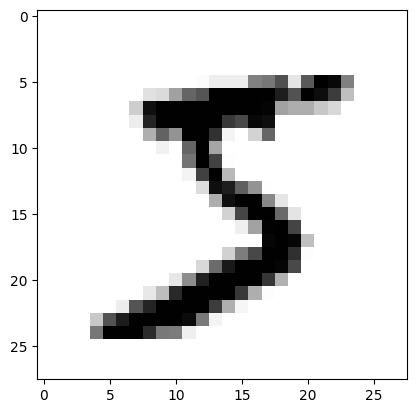

In [5]:
# Här kan vi se den första siffran i det första exemplet i datasetet, som är en 5:a.
# Datan är 28x28 pixlar (784), och cmap=plt.cm.binary gör att det visas i svartvitt.

some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap=plt.cm.binary)
print("True label for this image is:", y[0])

In [6]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [7]:
# Original tanke: Datan delas upp i träningsdata (60000) och testdata (10000) som rekomenderas av datasetets skapare.
# Nu behöver jag begränsa antalet observationer, så det blir 2000 till test, 2000 till validering och 6000 till träning.

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=2000, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=2000, random_state=42)

In [8]:
# Jag följer boken och tränar tre olika modeller: Logistic Regression, Random Forest och Extra Trees.
# n_estimators=100 betyder att varje träd i skogen kommer att ha 100 träd.

logreg_clf = LogisticRegression(max_iter=1000)
random_forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
extra_trees_clf = ExtraTreesClassifier(n_estimators=100, random_state=42)

# Skapa en lista med de namngivna estimatorerna som ska användas i VotingClassifier
named_estimators = [("logreg_clf", logreg_clf), ("random_forest_clf", random_forest_clf), ("extra_trees_clf", extra_trees_clf)]

# voting="hard" betyder att klassificeringen bestäms av majoritetsröstning.
voting_clf = VotingClassifier(named_estimators, voting="hard")

models = [logreg_clf, random_forest_clf, extra_trees_clf, voting_clf]
model_names = ["Logistic Regression", "Random Forest", "Extra Trees", "Voting Classifier"]

# Träna alla modeller på träningsdatan med for-loop
for model in models:
    model.fit(X_train, y_train)

# Här visas andelen korrekta klassificeringar (accuracy) för varje modell på valideringsdatan.
# Vi ser här att extra tree har högst accuracy.
print("Each model's accuracy on the validation data:") 
print("------------------------------------------------")

for name, model in zip(model_names, models):
    score = model.score(X_val, y_val)
    print(f"{name}: {score:.4f}")

c:\Users\marin\Downloads\Python\envs\dataarkitekture\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\marin\Downloads\Python\envs\dataarkitekture\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://sciki

Each model's accuracy on the validation data:
------------------------------------------------
Logistic Regression: 0.9105
Random Forest: 0.9605
Extra Trees: 0.9680
Voting Classifier: 0.9645


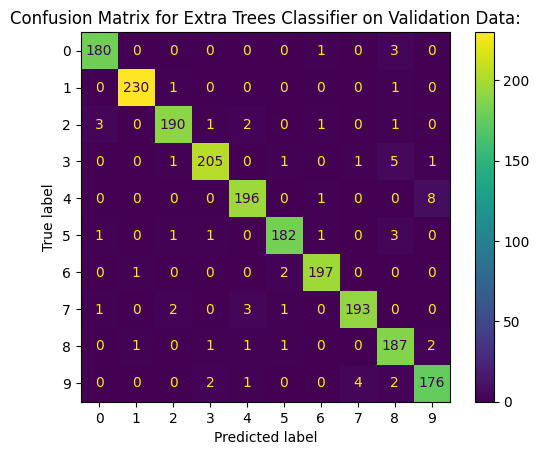

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       184
           1       0.99      0.99      0.99       232
           2       0.97      0.96      0.97       198
           3       0.98      0.96      0.97       214
           4       0.97      0.96      0.96       205
           5       0.97      0.96      0.97       189
           6       0.98      0.98      0.98       200
           7       0.97      0.96      0.97       200
           8       0.93      0.97      0.95       193
           9       0.94      0.95      0.95       185

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



In [9]:
# Nu inspekteras bäst presterande modellen (Extra Trees) närmare med hjälp av confusion matrix och classification report.
# Funktionen display_confusion_matrix används för att visa confusion matrix på ett snyggt sätt.
# Modellen presterar väldigt bra, med hög precision och recall för alla klasser.

et_pred_val = extra_trees_clf.predict(X_val)
display_confusion_matrix(y_val, et_pred_val)
plt.title("Confusion Matrix for Extra Trees Classifier on Validation Data:")
plt.show()

print(classification_report(y_val, et_pred_val))

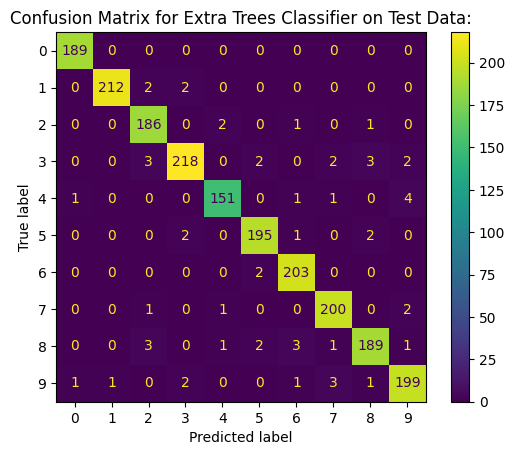

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       189
           1       1.00      0.98      0.99       216
           2       0.95      0.98      0.97       190
           3       0.97      0.95      0.96       230
           4       0.97      0.96      0.96       158
           5       0.97      0.97      0.97       200
           6       0.97      0.99      0.98       205
           7       0.97      0.98      0.97       204
           8       0.96      0.94      0.95       200
           9       0.96      0.96      0.96       208

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



In [10]:
# Nu tränas om modelllen på hela träningsdatan (train & val) och sedan utvärderas den på testdatan.
extra_trees_clf.fit(X_train_val, y_train_val)

# Utvärdera modellen på testdatan
et_pred_test = extra_trees_clf.predict(X_test)

# Funktionen används igen för testdatan
display_confusion_matrix(y_test, et_pred_test)
plt.title("Confusion Matrix for Extra Trees Classifier on Test Data:")
plt.show()

print(classification_report(y_test, et_pred_test))

# Vi ser här att modellen presterar lite sämre på testdatan än på valideringsdatan, vilket är vanligt eftersom modellen inte har sett testdatan tidigare.

In [11]:
# Modellen ska nu tränas om på hela datasetet innan produktionsättning, så att den kan dra nytta av all tillgänglig data.
final_model = ExtraTreesClassifier(n_estimators=100, random_state=42)
final_model.fit(X, y)

# Modellen sparas så att jag kan använda den i Streamlit appen.
joblib.dump(final_model, "final_mnist_model.joblib")

['final_mnist_model.joblib']